In [ ]:
!pip install vaderSentiment

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [ ]:
df = pd.read_csv('/content/AirlineScrappedReview_Cleaned_seif_we_ibra#1.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2807 entries, 0 to 2806
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Passanger_Name   2807 non-null   object 
 1   Route            2807 non-null   object 
 2   Rating           2807 non-null   float64
 3   Verified         2807 non-null   object 
 4   Review_title     2807 non-null   object 
 5   Review_content   2807 non-null   object 
 6   Traveller_Type   2807 non-null   object 
 7   Class            2807 non-null   object 
 8   Start_Location   2807 non-null   object 
 9   End_Location     2807 non-null   object 
 10  Layover_Route    484 non-null    object 
 11  Start_Latitude   2747 non-null   float64
 12  Start_Longitude  2747 non-null   float64
 13  Start_Address    2807 non-null   object 
 14  End_Latitude     2708 non-null   float64
 15  End_Longitude    2708 non-null   float64
 16  End_Address      2807 non-null   object 
dtypes: float64(5),

In [ ]:

df = df[df['Class'] != "Unknown"].reset_index(drop=True)
df = df[df['Traveller_Type'] != "Unknown"].reset_index(drop=True)
df = df[df['Traveller_Type'] != "Various"].reset_index(drop=True)

encoder = OneHotEncoder(sparse_output=False)
one_hot_encoded = encoder.fit_transform(df[['Class', 'Traveller_Type', 'Verified']])
one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(['Class', 'Traveller_Type', 'Verified']))

df = pd.concat([df.drop(['Class', 'Traveller_Type', 'Verified'], axis=1), one_hot_df], axis=1)

In [ ]:
df = df.drop(['Start_Latitude', 'Start_Longitude', 'End_Latitude', 'End_Longitude', 'Verified_Not Verified'], axis=1)

In [ ]:
df

,Passanger_Name,Route,Rating,Review_title,Review_content,Start_Location,End_Location,Layover_Route,Start_Address,End_Address,Class_Business Class,Class_Economy Class,Class_First Class,Class_Premium Economy,Traveller_Type_Business,Traveller_Type_Couple Leisure,Traveller_Type_Family Leisure,Traveller_Type_Solo Leisure,Verified_Trip Verified
0,Paige Boet,New Orleans to London,1.0,The airline lost my luggage,The airline lost my luggage and was absolutely...,New Orleans,London,NaN,"New Orleans, Orleans Parish, Louisiana, United...","London, Greater London, England, United Kingdom",0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
1,S Layne,London to Amman,1.0,fully refunded by our travel insurance,"We booked on the BA website, round trip flight...",London,Amman,NaN,"London, Greater London, England, United Kingdom","عمان, ناحية عمان, لواء قصبة عمان, عمان, 11110,...",1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,E Lanewoski,Heathrow to Bodrum,2.0,no boarding drinks provided,"First time flying with BA business class, neve...",London Heathrow,Bodrum,NaN,"London Heathrow Airport, The Beacon Roundabout...","Bodrum, Muğla, Ege Bölgesi, Türkiye",1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
3,Joel Burman,Amman to London,4.0,WiFi didn't work,You can buy sandwiches and crisps but don't ex...,Amman,London,NaN,"عمان, ناحية عمان, لواء قصبة عمان, عمان, 11110,...","London, Greater London, England, United Kingdom",0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,R Vines,London City to Ibiza,7.0,stick with economy,This is a two-for-one review covering economy ...,London City,Ibiza,NaN,"London City Airport, Connaught Road, Silvertow...","Eivissa, Illes Balears, España",1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2798,Sasha Guignard,Kiev to London,8.0,British Airways customer review,Flew from Kiev to London on their Airbus 319 i...,Kiev,London,NaN,"Київ, Україна","London, Greater London, England, United Kingdom",1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2799,D Ross,London-Vancouver,7.0,British Airways customer review,LHR to YVR return. Hard earned Avios points tr...,London,Vancouver,NaN,"London, Greater London, England, United Kingdom","Vancouver, Metro Vancouver Regional District, ...",1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2800,J Brown,LHR-ORD,5.0,British Airways customer review,Club World from LHR-ORD. Busy flight on the ag...,London Heathrow,"Chicago (IL), O'Hare International Airport",NaN,"London Heathrow Airport, The Beacon Roundabout...","O'Hare International Airport, 10000, West Higg...",1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2801,Kevin Barrance,BOM-LHR,3.0,British Airways customer review,This review refers to a return trip from India...,Bombay (Mumbai) - Chhatrapati Shivaji Internat...,London Heathrow,NaN,Chhatrapati Shivaji Maharaj International Airp...,"London Heathrow Airport, Northern Perimeter Ro...",0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0


In [ ]:
# Add the "Satisfied" column
df['Satisfied'] = (df['Rating'] >= 5).astype(int)

# Verify the new column
print("Satisfied column added!")
print("\nValue counts:")
print(df['Satisfied'].value_counts())

print("\nBreakdown by Rating:")
print(df.groupby('Rating')['Satisfied'].value_counts().unstack(fill_value=0))

print("\nSample rows:")
print(df[['Passanger_Name', 'Rating', 'Satisfied']].head(10))

# Check the dataframe info
print("\nUpdated DataFrame info:")
df.info()

Satisfied column added!

Value counts:
Satisfied
0    1586
1    1217
Name: count, dtype: int64

Breakdown by Rating:
Satisfied    0    1
Rating             
1.0        707    0
2.0        341    0
3.0        343    0
4.0        195    0
5.0          0  174
6.0          0  135
7.0          0  221
8.0          0  267
9.0          0  207
10.0         0  213

Sample rows:
   Passanger_Name  Rating  Satisfied
0      Paige Boet     1.0          0
1         S Layne     1.0          0
2     E Lanewoski     2.0          0
3     Joel Burman     4.0          0
4         R Vines     7.0          1
5          M King     1.0          0
6          C Dean     1.0          0
7  Richard Hodges     7.0          1
8  Carol Willmore     1.0          0
9   Nadine Kohler     1.0          0

Updated DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2803 entries, 0 to 2802
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                   

In [ ]:
df['Layover_Route'] = df['Layover_Route'].fillna('None')

In [ ]:
df['Route'].value_counts()

,count
Route,
London to Johannesburg,16
London to Cape Town,15
Vancouver to London,13
BKK to LHR,13
Johannesburg to London,13
...,...
BOM-LHR,1
LHR to Santorini,1
Seattle to Nice via London,1


In [ ]:
df['Route'] = df['Route'].str.replace('Cape Town to ', 'CPT to ')
df['Route'] = df['Route'].str.replace('Johannesburg to ', 'JNB to ')
df['Route'] = df['Route'].str.replace(' to Johannesburg', ' to JNB')
df['Route'] = df['Route'].str.replace(' to Cape Town', ' to CPT')
df['Route'] = df['Route'].str.replace('London Heathrow to ', 'LHR to ')
df['Route'] = df['Route'].str.replace(' to London Heathrow', ' to LHR')
df['Route'] = df['Route'].str.replace('London Gatwick to ', 'LGW to ')
df['Route'] = df['Route'].str.replace(' to London Gatwick', ' to LGW')
df['Route'] = df['Route'].str.replace(' to Hong Kong', ' to HKG')
df['Route'] = df['Route'].str.replace('Hong Kong to ', ' HKG to')
df['Route'] = df['Route'].str.replace(' to San Francisco', ' to SFO')
df['Route'] = df['Route'].str.replace('San Francisco to ', ' SFO to')
df['Route'] = df['Route'].str.replace(' to Rotterdam', ' to RTM')
df['Route'] = df['Route'].str.replace('Rotterdam to ', ' RTM to')
df['Route'] = df['Route'].str.replace(' to Muscat', ' to MCT')
df['Route'] = df['Route'].str.replace('Muscat to ', ' MCT to')
df['Route'] = df['Route'].str.replace(' to Lisbon', ' to LIS')
df['Route'] = df['Route'].str.replace('Lisbon to ', ' LIS to')
df['Route'] = df['Route'].str.replace(' to London-Heathrow', ' to LHR')
df['Route'] = df['Route'].str.replace('London-Heathrow to ', ' LHR to')
df['Route'] = df['Route'].str.replace(' via London-Heathrow', ' via LHR')
df['Route'] = df['Route'].str.replace(' via London Heathrow', ' via LHR')
df['Route'] = df['Route'].str.replace(' via Heathrow', ' via LHR')
df['Route'] = df['Route'].str.replace(' to Heathrow', ' to LHR')
df['Route'] = df['Route'].str.replace('Heathrow to ', 'LHR to')
df['Route'] = df['Route'].str.replace('to London UK (Heathrow)', 'LHR to')
df['Route'] = df['Route'].str.replace('Heathrow (London) to ', 'LHR to')
df['Route'] = df['Route'].str.replace('Ibiza to ', 'IBZ to ')
df['Route'] = df['Route'].str.replace(' to Ibiza', ' to IBZ')
df['Route'] = df['Route'].str.replace(' toIbiza', ' to IBZ')
df['Route'] = df['Route'].str.replace('Bodrum to ', 'BJV to ')
df['Route'] = df['Route'].str.replace(' to Bodrum', ' to BJV')
df['Route'] = df['Route'].str.replace(' toBodrum', ' to BJV')
df['Route'] = df['Route'].str.replace('Aberdeen to ', 'ABZ to ')
df['Route'] = df['Route'].str.replace(' to Aberdeen', ' to ABZ')
df['Route'] = df['Route'].str.replace('Tampa to ', 'TPA to ')
df['Route'] = df['Route'].str.replace(' to Tampa', ' to TPA')
df['Route'] = df['Route'].str.replace('Gatwick to ', 'LGW to ')
df['Route'] = df['Route'].str.replace(' to Gatwick', ' to LGW')
df['Route'] = df['Route'].str.replace('Islamabad to ', 'ISB to ')
df['Route'] = df['Route'].str.replace(' to Islamabad', ' to ISB')
df['Route'] = df['Route'].str.replace('Dallas Fort-Worth to ', 'DFW to ')
df['Route'] = df['Route'].str.replace('Dallas Ft Worth to ', 'DFW to ')
df['Route'] = df['Route'].str.replace('Dallas to ', 'DFW to ')
df['Route'] = df['Route'].str.replace(' to Dallas', ' to DFW')
df['Route'] = df['Route'].str.replace('Geneva to ', 'GVA to ')
df['Route'] = df['Route'].str.replace(' to Geneva', ' to GVA')
df['Route'] = df['Route'].str.replace('Barbados to ', 'BGI to ')
df['Route'] = df['Route'].str.replace(' to Barbados', ' to BGI')
df['Route'] = df['Route'].str.replace('Bridgetown to ', 'BGI to ')
df['Route'] = df['Route'].str.replace(' to Bridgetown', ' to BGI')
df['Route'] = df['Route'].str.replace(' to Genoa', ' to GOA')
df['Route'] = df['Route'].str.replace(' to Nice', ' to NCE')
df['Route'] = df['Route'].str.replace('Nice to DFW via London', 'NCE to DFW via London')
df['Route'] = df['Route'].str.replace('Nice to Kuwait via London', 'NCE to KWI via London')
df['Route'] = df['Route'].str.replace('Nice to LGW', 'NCE to LGW')
df['Route'] = df['Route'].str.replace('Nice to LHR', 'NCE to LHR')
df['Route'] = df['Route'].str.replace('Oakland to ', 'OAK to ')
df['Route'] = df['Route'].str.replace('Kuwait to ', 'KWI to ')
df['Route'] = df['Route'].str.replace(' to Geneva', ' to GVA')
df['Route'] = df['Route'].str.replace('Barbados to ', 'BGI to ')
df['Route'] = df['Route'].str.replace(' to Male', ' to MLE')
df['Route'] = df['Route'].str.replace('Male to ', 'MLE to ')
df['Route'] = df['Route'].str.replace(' to Malaga', ' to AGP')
df['Route'] = df['Route'].str.replace(' toMalaga', ' to AGP')
df['Route'] = df['Route'].str.replace('Malaga to ', 'AGP to ')
df['Route'] = df['Route'].str.replace(' to Newcastle', ' to NCL')
df['Route'] = df['Route'].str.replace('Newcastle to ', 'NCL to ')
df['Route'] = df['Route'].str.replace(' to Florence', ' to FLR')
df['Route'] = df['Route'].str.replace('-Florence', ' to FLR')
df['Route'] = df['Route'].str.replace('Florence to ', 'FLR to ')
df['Route'] = df['Route'].str.replace(' to Brindisi', ' to BDS')
df['Route'] = df['Route'].str.replace('Brindisi to ', 'BDS to ')
df['Route'] = df['Route'].str.replace(' to Gibraltar', ' to GIB')
df['Route'] = df['Route'].str.replace('Gibraltar to ', 'GIB to ')
df['Route'] = df['Route'].str.replace(' to Bangalore', ' to BLR')
df['Route'] = df['Route'].str.replace('Bangalore to ', 'BLR to ')
df['Route'] = df['Route'].str.replace(' to Amsterdam', ' to AMS')
df['Route'] = df['Route'].str.replace(' toAmsterdam', ' to AMS')
df['Route'] = df['Route'].str.replace('Amsterdam to ', 'AMS to ')
df['Route'] = df['Route'].str.replace(' to Prague', ' to PRG')
df['Route'] = df['Route'].str.replace('Prague to ', 'PRG to ')
df['Route'] = df['Route'].str.replace(' to Zagreb', ' to ZAG')
df['Route'] = df['Route'].str.replace('Zagreb to ', 'ZAG to ')
df['Route'] = df['Route'].str.replace(' to Tehran', ' to THR')
df['Route'] = df['Route'].str.replace('Tehran to ', 'THR to ')
df['Route'] = df['Route'].str.replace(' to Seville', ' to SVQ')
df['Route'] = df['Route'].str.replace('Seville to ', 'SVQ to ')
df['Route'] = df['Route'].str.replace(' to Belfast', ' to BFS')
df['Route'] = df['Route'].str.replace('Belfast to ', 'BFS to ')
df['Route'] = df['Route'].str.replace(' toBelfast', ' to BFS')
df['Route'] = df['Route'].str.replace('Belfast  to ', 'BFS to ')
df['Route'] = df['Route'].str.replace('Belfast City to ', 'BFS to ')
df['Route'] = df['Route'].str.replace('toJFK (New York City)', 'to JFK')
df['Route'] = df['Route'].str.replace('Edinburgh to ', 'EDI to ')
df['Route'] = df['Route'].str.replace('to Edinburgh', 'to EDI')
df['Route'] = df['Route'].str.replace('toEdinburgh', 'to EDI')
df['Route'] = df['Route'].str.replace(' to Riyadh', 'to RUH')
df['Route'] = df['Route'].str.replace('Riyadh to', 'RUH to ')
df['Route'] = df['Route'].str.replace('Santorini to ', 'JTR to ')
df['Route'] = df['Route'].str.replace(' to Santorini', ' to JTR')
df['Route'] = df['Route'].str.replace(' toSantorini', ' to JTR')
df['Route'] = df['Route'].str.replace(' to Murcia', ' to RMU')
df['Route'] = df['Route'].str.replace('Manchester to ', 'MAN to ')
df['Route'] = df['Route'].str.replace('Manchester, UK to ', 'MAN to ')
df['Route'] = df['Route'].str.replace(' to Manchester', ' to MAN')
df['Route'] = df['Route'].str.replace(' toManchester', ' to MAN')
df['Route'] = df['Route'].str.replace('Helsinki to ', 'HEL to ')
df['Route'] = df['Route'].str.replace(' to Helsinki', ' to HEL')
df['Route'] = df['Route'].str.replace('Tokyo Narita to ', 'NRT to ')
df['Route'] = df['Route'].str.replace(' to Tokyo Narita', ' to NRT')
df['Route'] = df['Route'].str.replace('San Francisco to ', 'SFO to ')
df['Route'] = df['Route'].str.replace(' to San Francisco', ' to SFO')
df['Route'] = df['Route'].str.replace(' to San francisco', ' to SFO')
df['Route'] = df['Route'].str.replace(' to san Francisco', ' to SFO')
df['Route'] = df['Route'].str.replace(' to San Fran', ' to SFO')
df['Route'] = df['Route'].str.replace('Nairobi to ', 'NBO to ')
df['Route'] = df['Route'].str.replace(' to Nairobi', ' to NBO')
df['Route'] = df['Route'].str.replace('Jeddah to ', 'JED to ')
df['Route'] = df['Route'].str.replace(' to Jeddah', ' to JED')
df['Route'] = df['Route'].str.replace('Houston to ', 'IAH to ')
df['Route'] = df['Route'].str.replace(' to Houston', ' to IAH')
df['Route'] = df['Route'].str.replace(' toHouston', ' to IAH')
df['Route'] = df['Route'].str.replace(' to Lyon', ' to LYS')
df['Route'] = df['Route'].str.replace(' toLyon', ' to LYS')
df['Route'] = df['Route'].str.replace('Lyon to ', 'LYS to ')
df['Route'] = df['Route'].str.replace('Seoul to ', 'ICN to ')
df['Route'] = df['Route'].str.replace(' to Seoul', ' to ICN')
df['Route'] = df['Route'].str.replace('Vienna to ', 'VIE to ')
df['Route'] = df['Route'].str.replace(' to Vienna', ' to VIE')
df['Route'] = df['Route'].str.replace(' toVienna', ' to VIE')
df['Route'] = df['Route'].str.replace('Bermuda to ', 'BDA to ')
df['Route'] = df['Route'].str.replace(' to Bermuda', ' to BDA')
df['Route'] = df['Route'].str.replace('Marseille to ', 'MRS to ')
df['Route'] = df['Route'].str.replace(' to Marseille', ' to MRS')
df['Route'] = df['Route'].str.replace(' toMarseille', ' to MRS')
df['Route'] = df['Route'].str.replace('London to CPT', 'LHR to CPT')
df['Route'] = df['Route'].str.replace('London to JNB', 'LHR to JNB')
df['Route'] = df['Route'].str.replace('Los Angeles to London', 'LAX to LHR')
df['Route'] = df['Route'].str.replace('JNB to London', 'JNB to LHR')
df['Route'] = df['Route'].str.replace('London to Athens', 'LHR to ATH')
df['Route'] = df['Route'].str.replace(' to Athens', ' to ATH')
df['Route'] = df['Route'].str.replace('Athens to ', 'ATH to ')
df['Route'] = df['Route'].str.replace('HKG toLondon', 'HKG to LHR')
df['Route'] = df['Route'].str.replace('SFO toLondon', 'SFO to LHR')
df['Route'] = df['Route'].str.replace('Vancouver to London', 'YVR to LHR')
df['Route'] = df['Route'].str.replace('Vancouver to ', 'YVR to ')
df['Route'] = df['Route'].str.replace(' to Vancouver', ' to YVR')
df['Route'] = df['Route'].str.replace('CPT to London', 'CPT to LHR')
df['Route'] = df['Route'].str.replace('CPT to London', 'CPT to LHR')
df['Route'] = df['Route'].str.replace('CPT to London', 'CPT to LHR')
df['Route'] = df['Route'].str.replace('London to Toronto', 'LHR to YYZ')
df['Route'] = df['Route'].str.replace(' to Toronto', ' to YYZ')
df['Route'] = df['Route'].str.replace('Toronto to ', 'YYZ to ')
df['Route'] = df['Route'].str.replace('Singapore to London', 'SIN to LHR')
df['Route'] = df['Route'].str.replace('London to HKG', 'LHR to HKG')
df['Route'] = df['Route'].str.replace('Faro to ', 'FAO to ')
df['Route'] = df['Route'].str.replace(' to Faro', ' to FAO')
df['Route'] = df['Route'].str.replace(' toFaro', ' to FAO')
df['Route'] = df['Route'].str.replace('Shannon', 'SNN')
df['Route'] = df['Route'].str.replace('Hamburg to ', 'HAM to ')
df['Route'] = df['Route'].str.replace(' to Hamburg', ' to HAM')
df['Route'] = df['Route'].str.replace('Calgary to ', 'CYY to ')
df['Route'] = df['Route'].str.replace(' to Calgary', ' to CYY')
df['Route'] = df['Route'].str.replace('Zurich to ', 'ZRH to ')
df['Route'] = df['Route'].str.replace(' to Zurich', ' to ZRH')
df['Route'] = df['Route'].str.replace(' toZurich', ' to ZRH')
df['Route'] = df['Route'].str.replace('Dublin to ', 'DUB to ')
df['Route'] = df['Route'].str.replace(' to Dublin', ' to DUB')
df['Route'] = df['Route'].str.replace('Durban to ', 'DUR to ')
df['Route'] = df['Route'].str.replace(' to Durban', ' to DUR')
df['Route'] = df['Route'].str.replace('Dubai to ', 'DXB to ')
df['Route'] = df['Route'].str.replace(' to Dubai', ' to DXB')
df['Route'] = df['Route'].str.replace('Bahrain to ', 'BAH to ')
df['Route'] = df['Route'].str.replace(' to Bahrain', ' to BAH')
df['Route'] = df['Route'].str.replace('Tirana Rinas to ', 'TIA to ')
df['Route'] = df['Route'].str.replace(' to Tirana Rinas', ' to TIA')
df['Route'] = df['Route'].str.replace('New York JFK to ', 'JFK to ')
df['Route'] = df['Route'].str.replace(' to New York JFK', ' to JFK')
df['Route'] = df['Route'].str.replace('Larnaca to ', 'LCA to ')
df['Route'] = df['Route'].str.replace(' to Larnaca', ' to LCA')
df['Route'] = df['Route'].str.replace(' toJNB', ' to JNB')
df['Route'] = df['Route'].str.replace(' toLas Vegas', ' to LAS')
df['Route'] = df['Route'].str.replace('Las Vegas to ', 'LAS to ')
df['Route'] = df['Route'].str.replace(' to Las Vegas', ' to LAS')
df['Route'] = df['Route'].str.replace('Phoenix to ', 'PHX to ')
df['Route'] = df['Route'].str.replace(' to Phoenix', ' to PHX')
df['Route'] = df['Route'].str.replace('Los Angeles to ', 'LAX to ')
df['Route'] = df['Route'].str.replace(' to Los Angeles', ' to LAX')
df['Route'] = df['Route'].str.replace('Singapore to ', 'SIN to ')
df['Route'] = df['Route'].str.replace(' to Singapore', ' to SIN')
df['Route'] = df['Route'].str.replace('Boston to ', 'BOS to ')
df['Route'] = df['Route'].str.replace(' to Boston', ' to BOS')
df['Route'] = df['Route'].str.replace('Funchal to ', 'FNC to ')
df['Route'] = df['Route'].str.replace(' to Funchal', ' to FNC')
df['Route'] = df['Route'].str.replace('London to ', 'LHR to ')
df['Route'] = df['Route'].str.replace(' to London', ' to LHR')
df['Route'] = df['Route'].str.replace(' toLondon', ' to LHR')
df['Route'] = df['Route'].str.replace('Kuala Lumpur to ', 'KUL to ')
df['Route'] = df['Route'].str.replace(' to Kuala Lumpur', ' to KUL')
df['Route'] = df['Route'].str.replace(' toKuala Lumpur', ' to KUL')
df['Route'] = df['Route'].str.replace(' to Kuala lumpur', ' to KUL')
df['Route'] = df['Route'].str.replace('Brussels to ', 'CRL to ')
df['Route'] = df['Route'].str.replace(' to Brussels', ' to CRL')
df['Route'] = df['Route'].str.replace(' toBrussels', ' to CRL')
df['Route'] = df['Route'].str.replace('Istanbul to ', 'IST to ')
df['Route'] = df['Route'].str.replace(' to Istanbul', ' to IST')
df['Route'] = df['Route'].str.replace('Stockholm to ', 'ARN to ')
df['Route'] = df['Route'].str.replace(' to Stockholm', ' to ARN')
df['Route'] = df['Route'].str.replace('Arlanda Stockholm to ', 'ARN to ')
df['Route'] = df['Route'].str.replace(' to Arlanda Stockholm', ' to ARN')
df['Route'] = df['Route'].str.replace('Stockholm Arlanda to ', 'ARN to ')
df['Route'] = df['Route'].str.replace(' to Stockholm Arlanda', ' to ARN')
df['Route'] = df['Route'].str.replace('Bangkok to ', 'BKK to ')
df['Route'] = df['Route'].str.replace(' to Bangkok', ' to BKK')
df['Route'] = df['Route'].str.replace(' toBangkok', ' to BKK')
df['Route'] = df['Route'].str.replace('Madrid to ', 'MAD to ')
df['Route'] = df['Route'].str.replace(' to Madrid', ' to MAD')
df['Route'] = df['Route'].str.replace('Berlin to ', 'TXL to ')
df['Route'] = df['Route'].str.replace(' to Berlin', ' to TXL')
df['Route'] = df['Route'].str.replace('Berlin Tegel to ', 'TXL to ')
df['Route'] = df['Route'].str.replace('Sydney to ', 'SYD to ')
df['Route'] = df['Route'].str.replace(' to Sydney', ' to SYD')
df['Route'] = df['Route'].str.replace('Cancun to ', 'CUN to ')
df['Route'] = df['Route'].str.replace(' to Cancun', ' to CUN')
df['Route'] = df['Route'].str.replace(' toCancun', ' to CUN')
df['Route'] = df['Route'].str.replace(" to Chicago O'Hare", ' to ORD')
df['Route'] = df['Route'].str.replace('Chicago to ', 'ORD to ')
df['Route'] = df['Route'].str.replace(' to Chicago', ' to ORD')
df['Route'] = df['Route'].str.replace('New York to ', 'JFK to ')
df['Route'] = df['Route'].str.replace(' to New York', ' to JFK')
df['Route'] = df['Route'].str.replace('New York to ', 'JFK to ')
df['Route'] = df['Route'].str.replace(' to New York', ' to JFK')
df['Route'] = df['Route'].str.replace('Mauritius to ', 'MRU to ')
df['Route'] = df['Route'].str.replace(' to Mauritius', ' to MRU')
df['Route'] = df['Route'].str.replace('Algiers to ', 'ALG to ')
df['Route'] = df['Route'].str.replace(' to Algiers', ' to ALG')
df['Route'] = df['Route'].str.replace('Punta Cana to ', 'PUJ to ')
df['Route'] = df['Route'].str.replace(' to Punta Cana', ' to PUJ')
df['Route'] = df['Route'].str.replace('Marrakech to ', 'RAK to ')
df['Route'] = df['Route'].str.replace(' to Marrakech', ' to RAK')
df['Route'] = df['Route'].str.replace('Lanzarote to ', 'ACE to ')
df['Route'] = df['Route'].str.replace(' to Lanzarote', ' to ACE')
df['Route'] = df['Route'].str.replace('Krakow to ', 'KRK to ')
df['Route'] = df['Route'].str.replace(' to Krakow', ' to KRK')
df['Route'] = df['Route'].str.replace('Kefalonia to ', 'EFL to ')
df['Route'] = df['Route'].str.replace(' to Kefalonia', ' to EFL')
df['Route'] = df['Route'].str.replace('Tel Aviv to ', 'TLV to ')
df['Route'] = df['Route'].str.replace(' to Tel Aviv', ' to TLV')
df['Route'] = df['Route'].str.replace('Seattle to ', 'SEA to ')
df['Route'] = df['Route'].str.replace(' to Seattle', ' to SEA')
df['Route'] = df['Route'].str.replace('Washington to ', 'SEA to ')
df['Route'] = df['Route'].str.replace(' to Washington', ' to SEA')
df['Route'] = df['Route'].str.replace('Washington DC to ', 'SEA to ')
df['Route'] = df['Route'].str.replace('Copenhagen to ', 'CPH to ')
df['Route'] = df['Route'].str.replace(' to Copenhagen', ' to CPH')
df['Route'] = df['Route'].str.replace(' toCopenhagen', ' to CPH')
df['Route'] = df['Route'].str.replace(' to Denver', ' to DEN')
df['Route'] = df['Route'].str.replace('Denver to ', 'DEN to ')
df['Route'] = df['Route'].str.replace(' to Barcelona', ' to BCN')
df['Route'] = df['Route'].str.replace('Barcelona to ', 'BCN to ')
df['Route'] = df['Route'].str.replace(' to Gothenburg', ' to GOT')
df['Route'] = df['Route'].str.replace('Gothenburg to ', 'GOT to ')
df['Route'] = df['Route'].str.replace(' to Jersey', ' to JER')
df['Route'] = df['Route'].str.replace('Jersey to ', 'JER to ')
df['Route'] = df['Route'].str.replace(' to Lebanon', ' to BEY')
df['Route'] = df['Route'].str.replace('Lebanon to ', 'BEY to ')
df['Route'] = df['Route'].str.replace(' to Mallorca', ' to PMI')
df['Route'] = df['Route'].str.replace('Mallorca to ', 'PMI to ')
df['Route'] = df['Route'].str.replace(' to Venice Marco Polo', ' to VCE')
df['Route'] = df['Route'].str.replace('Venice Marco Polo to ', 'VCE to ')
df['Route'] = df['Route'].str.replace(' to Venice', ' to VCE')
df['Route'] = df['Route'].str.replace('Venice to ', 'VCE to ')
df['Route'] = df['Route'].str.replace(' to  Gatwick', ' to LGW')
df['Route'] = df['Route'].str.replace(' to Doha', ' to DOH')
df['Route'] = df['Route'].str.replace('Doha to ', 'DOH to ')
df['Route'] = df['Route'].str.replace(' to Doha', ' to DOH')
df['Route'] = df['Route'].str.replace('Paris CDG to ', 'CDG to ')
df['Route'] = df['Route'].str.replace('to Paris CDG', 'to CDG')
df['Route'] = df['Route'].str.replace('Paris CDG to ', 'CDG to ')
df['Route'] = df['Route'].str.replace('to Paris Orly', 'to ORY')
df['Route'] = df['Route'].str.replace('Istanbul to ', 'IST to ')
df['Route'] = df['Route'].str.replace(' to Istanbul', ' to IST')
df['Route'] = df['Route'].str.replace('Stockholm to ', 'ARN to ')
df['Route'] = df['Route'].str.replace(' to Stockholm', ' to ARN')
df['Route'] = df['Route'].str.replace('Arlanda Stockholm to ', 'ARN to ')
df['Route'] = df['Route'].str.replace(' to Arlanda Stockholm', ' to ARN')
df['Route'] = df['Route'].str.replace('Stockholm Arlanda to ', 'ARN to ')
df['Route'] = df['Route'].str.replace(' to Stockholm Arlanda', ' to ARN')
df['Route'] = df['Route'].str.replace('Bangkok to ', 'BKK to ')
df['Route'] = df['Route'].str.replace(' to Bangkok', ' to BKK')
df['Route'] = df['Route'].str.replace(' toBangkok', ' to BKK')
df['Route'] = df['Route'].str.replace('Madrid to ', 'MAD to ')
df['Route'] = df['Route'].str.replace(' to Madrid', ' to MAD')
df['Route'] = df['Route'].str.replace('Berlin to ', 'TXL to ')
df['Route'] = df['Route'].str.replace(' to Berlin', ' to TXL')
df['Route'] = df['Route'].str.replace('Berlin Tegel to ', 'TXL to ')
df['Route'] = df['Route'].str.replace('Sydney to ', 'SYD to ')
df['Route'] = df['Route'].str.replace(' to Sydney', ' to SYD')
df['Route'] = df['Route'].str.replace('Cancun to ', 'CUN to ')
df['Route'] = df['Route'].str.replace(' to Cancun', ' to CUN')
df['Route'] = df['Route'].str.replace(' toCancun', ' to CUN')
df['Route'] = df['Route'].str.replace('Miami to ', 'MIA to ')
df['Route'] = df['Route'].str.replace(' to Miami', ' to MIA')
df['Route'] = df['Route'].str.replace(' toMiami', ' to MIA')
df['Route'] = df['Route'].str.replace('Sofia to ', 'SOF to ')
df['Route'] = df['Route'].str.replace(' to Sofia', ' to SOF')
df['Route'] = df['Route'].str.replace('Delhi to ', 'DEL to ')
df['Route'] = df['Route'].str.replace(' to Delhi', ' to DEL')
df['Route'] = df['Route'].str.replace(' to Delhi Airport', ' to DEL')
df['Route'] = df['Route'].str.replace(' to New Delhi', ' to DEL')
df['Route'] = df['Route'].str.replace(' to Frankfurt', ' to FRA')
df['Route'] = df['Route'].str.replace('Frankfurt to ', 'FRA to ')
df['Route'] = df['Route'].str.replace(' to Glasgow', ' to GLA')
df['Route'] = df['Route'].str.replace('Glasgow to ', 'GLA to ')
df['Route'] = df['Route'].str.replace(' toGlasgow', ' to GLA')
df['Route'] = df['Route'].str.replace(' to Antigua', ' to ANU')
df['Route'] = df['Route'].str.replace('Antigua to ', 'ANU to ')
df['Route'] = df['Route'].str.replace(' to St Lucia', ' to UVF')
df['Route'] = df['Route'].str.replace('St Lucia to ', 'UVF to ')


In [ ]:
with pd.option_context('display.max_rows', None):
    display(df['Route'].value_counts())

,count
Route,
LHR to JFK,32
LHR to JNB,30
JFK to LHR,27
LHR to DXB,26
LHR to CPT,25
LHR to BKK,25
LHR to HKG,24
BKK to LHR,23
LHR to MIA,22


In [ ]:
heathrow_routes = df[df['Route'].str.contains('Brussels', case=False, na=False)]
display(heathrow_routes['Route'].value_counts())

,count
Route,


In [ ]:
heathrow_routes = df[df['Route'].str.contains('Milan ', case=False, na=False)]



In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Route_Encoded'] = le.fit_transform(df['Route'])

In [ ]:
df.columns

Index(['Passanger_Name', 'Route', 'Rating', 'Review_title', 'Review_content',
       'Start_Location', 'End_Location', 'Layover_Route', 'Start_Address',
       'End_Address', 'Class_Business Class', 'Class_Economy Class',
       'Class_First Class', 'Class_Premium Economy', 'Traveller_Type_Business',
       'Traveller_Type_Couple Leisure', 'Traveller_Type_Family Leisure',
       'Traveller_Type_Solo Leisure', 'Verified_Trip Verified', 'Satisfied',
       'Route_Encoded'],
      dtype='object')

In [ ]:
X = df[['Route_Encoded', 'Verified_Trip Verified',
        'Traveller_Type_Solo Leisure', 'Traveller_Type_Family Leisure',
        'Traveller_Type_Couple Leisure', 'Traveller_Type_Business','Class_Business Class', 'Class_Economy Class',
       'Class_First Class', 'Class_Premium Economy',]]  # You can modify

y = df['Satisfied']

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
random_state=42)

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.5793226381461676
Precision: 0.6583333333333333
Recall: 0.28832116788321166
F1 Score: 0.4010152284263959

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.86      0.68       287
           1       0.66      0.29      0.40       274

    accuracy                           0.58       561
   macro avg       0.61      0.57      0.54       561
weighted avg       0.61      0.58      0.54       561


Confusion Matrix:
[[246  41]
 [195  79]]


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras import Sequential, Input
from sklearn.preprocessing import StandardScaler
# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y,
test_size=0.2, random_state=42)

In [ ]:
print("Train data shape:",X_train.shape, "Train Label shape", y_train.shape)
print("Test data shape:",X_test.shape, "Test Label shape", y_test.shape)

Train data shape: (2242, 10) Train Label shape (2242,)
Test data shape: (561, 10) Test Label shape (561,)


In [ ]:
model = Sequential([
Input(shape=(X_train.shape[1],)),
layers.Dense(512, activation='tanh'),
layers.Dense(256, activation='relu'),
layers.Dense(128, activation='relu'),
layers.Dense(64, activation='relu'),
layers.Dense(32, activation='relu'),
layers.Dense(16, activation='relu'),
layers.Dense(8, activation='relu'),
layers.Dense(4, activation='relu'),
layers.Dense(2, activation='relu'),
layers.Dense(1, activation='sigmoid')  # binary classification
])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                │ (None, 512)            │         5,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 2)              │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 180,905 (706.66 KB)

 Trainable params: 180,905 (706.66 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_accuracy', patience=40, restore_best_weights=True)
model.compile(optimizer='adam',
loss='binary_crossentropy',
metrics=['accuracy',
Precision(name='precision'),
Recall(name='recall')])

In [ ]:
history = model.fit(X_train, y_train, epochs=100, validation_split=0.2,
verbose=1, callbacks=[early_stop])

Epoch 1/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.5736 - loss: 0.6773 - precision: 0.8017 - recall: 0.0170 - val_accuracy: 0.5679 - val_loss: 0.6823 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5784 - loss: 0.6560 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.5679 - val_loss: 0.6756 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6115 - loss: 0.6509 - precision: 0.2258 - recall: 0.0539 - val_accuracy: 0.6036 - val_loss: 0.6917 - val_precision: 0.5455 - val_recall: 0.4948
Epoch 4/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6310 - loss: 0.6508 - precision: 0.5671 - recall: 0.5971 - val_accuracy: 0.6147 - val_loss: 0.6747 - val_precision: 0.5636 - val_recall: 0.4794
Epoch 5/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6339 - loss: 0.6545 - precision: 0.5885 - recall: 0.5273 - val_accuracy: 

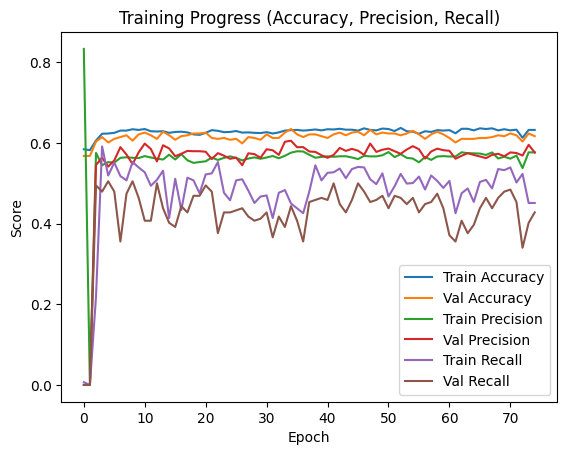

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')

plt.plot(history.history['precision'], label='Train Precision')
plt.plot(history.history['val_precision'], label='Val Precision')

plt.plot(history.history['recall'], label='Train Recall')
plt.plot(history.history['val_recall'], label='Val Recall')

plt.xlabel('Epoch')
plt.ylabel('Score')
plt.title('Training Progress (Accuracy, Precision, Recall)')
plt.legend()
plt.show()

In [ ]:
test_loss, test_accuracy, test_precision, test_recall = model.evaluate(X_test,
y_test, verbose=0)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Precision:", test_precision)
print("Test Recall:", test_recall)

Test Loss: 0.6910668611526489
Test Accuracy: 0.5953654050827026
Test Precision: 0.6124401688575745
Test Recall: 0.46715328097343445
